## **Experiment_01: Raw Image Retrieval Baseline**

**Retrieval using Image-Level Similarity**

Following the baseline notebook, we first evaluate pixel-level similarity methods: Mean Squared Error (MSE) and Structural Similarity Index Measure (SSIM).

| Method | Description |
|---|---|
| [MSE Similarity Measure](#mse)  | Pixel-level distance between the query image and each retrieval candidate. Lower MSE indicates higher similarity. |
| [SSIM Similarity Measure](#ssim)| Structural image-level similarity between the query image and each retrieval candidate. Higher SSIM indicates higher similarity. |

#### **Imports and paths**

In [ ]:
from pathlib import Path
import sys
import os
# import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

from skimage.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim

import torch

In [ ]:
# Used in later experiments

# SEED = 42

# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)

In [3]:
PROJECT_ROOT = Path.cwd().parents[2]
DATA_DIR = PROJECT_ROOT / "data"
PARTITION_CSV = DATA_DIR / "partition.csv"
IMAGES_DIR = PROJECT_ROOT / "8-Ball Pool.v3i.yolov11" / "train" / "images"
RETRIEVAL_DIR = PROJECT_ROOT / "detection_and_retrieval" / "retrieval"
if str(RETRIEVAL_DIR) not in sys.path:
    sys.path.append(str(RETRIEVAL_DIR))
RESULTS_DIR = RETRIEVAL_DIR / "outputs" / "experiment_01"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

assert PARTITION_CSV.exists(), f"Missing partition CSV: {PARTITION_CSV}"
assert IMAGES_DIR.exists(), f"Missing images directory: {IMAGES_DIR}"

In [4]:
len(os.listdir(IMAGES_DIR))

247

In [5]:
from utils.data import get_resnet_transform, load_retrieval_datasets, show_image, denormalize_image

#### **Load Dataset**

The retrieval pool is composed of the training images, while the query set is composed of the test images, following the split defined in `partition.csv`.

Each image is resized, center-cropped, converted to tensor format, and normalized using ImageNet statistics, matching the preprocessing used in the baseline notebook.

In [6]:
transform = get_resnet_transform()

retrieval_pool, query_data = load_retrieval_datasets(
    images_dir=IMAGES_DIR,
    partition_csv=PARTITION_CSV,
    transform=transform
)

print(f"Retrieval pool size: {len(retrieval_pool)}")
print(f"Query set size: {len(query_data)}")

sample_img, sample_name = query_data[0]

print(f"Sample query filename: {sample_name}")
print(f"Sample query tensor shape: {sample_img.shape}")
print(f"Sample query tensor dtype: {sample_img.dtype}")

Retrieval pool size: 207
Query set size: 20
Sample query filename: 107_png.rf.f31cf99275d8de0c817398bad1fbb98c.jpg
Sample query tensor shape: torch.Size([3, 224, 224])
Sample query tensor dtype: torch.float32


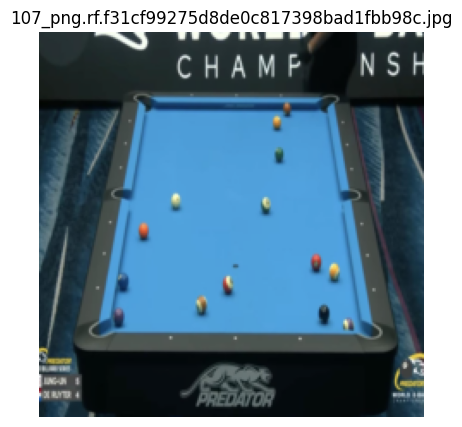

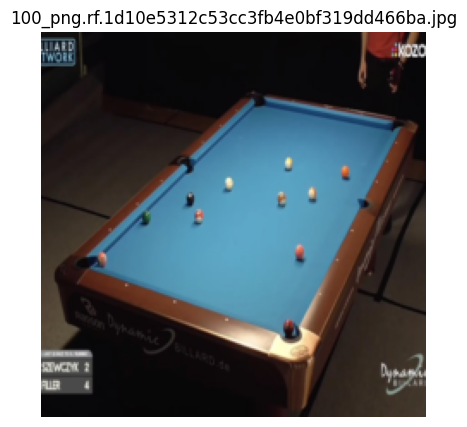

In [7]:
show_image(query_data, 0)
show_image(retrieval_pool, 1)

<a id="mse"></a>
### **Mean Squared Error (MSE) Retrieval**

Mean Squared Error measures the average squared pixel-wise difference between two images.

For two identical images, MSE equals zero. Larger values indicate larger visual differences.

Since MSE compares pixels directly, it is highly sensitive to viewpoint changes, translations, lighting variations, and camera pose.

- #### **Query Image**

We select one query image from the test set and use it as the reference image for the retrieval experiment. All retrieval candidates belong to the training set.

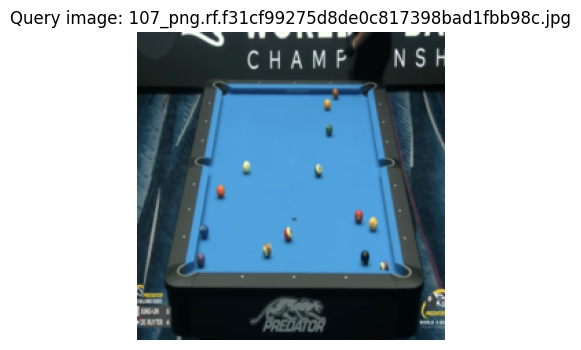

In [8]:
query_image, query_name = query_data[0] # Normalized query image 
query_image_denormalized = denormalize_image(query_image)

plt.figure(figsize=(4, 4))
plt.imshow(query_image_denormalized)
plt.title(f"Query image: {query_name}")
plt.axis("off")
plt.show()

- #### **Similarity computation**

In [9]:
def get_topk_mse(query_image, retrieval_pool, k=5):
    scores = np.zeros(len(retrieval_pool))

    query_np = query_image.detach().cpu().numpy()

    for i in range(len(retrieval_pool)):
        candidate_image, _ = retrieval_pool[i]
        candidate_np = candidate_image.detach().cpu().numpy()
        scores[i] = mean_squared_error(query_np, candidate_np)

    topk_idx = np.argsort(scores)[:k]
    return topk_idx, scores

In [10]:
top5_mse_idx, similarities_mse = get_topk_mse(
    query_image=query_image,
    retrieval_pool=retrieval_pool,
    k=5
)

In [11]:
print("Top-5 MSE results:")

for rank, idx in enumerate(top5_mse_idx, start=1):
    _, name = retrieval_pool[idx]

    print(
        f"{rank}. {name} | "
        f"MSE distance = {similarities_mse[idx]:.4f}"
    )

Top-5 MSE results:
1. 106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg | MSE distance = 0.0661
2. 110_png.rf.9a38b6057e543f83b58aa59b9748688b.jpg | MSE distance = 0.1033
3. 25f_png.rf.e20424d4f5cc6ff760cbfa7767c3ec32.jpg | MSE distance = 0.1203
4. 109_png.rf.0d8042ff3ef7a93feb5a18be8a42ca80.jpg | MSE distance = 0.1244
5. 24f_png.rf.ee5f961ec533993bb9907fa09380d92a.jpg | MSE distance = 0.1548


- #### **Top-5 Retrieved Images**

The five images with the lowest MSE values are returned as the most similar retrieval results.

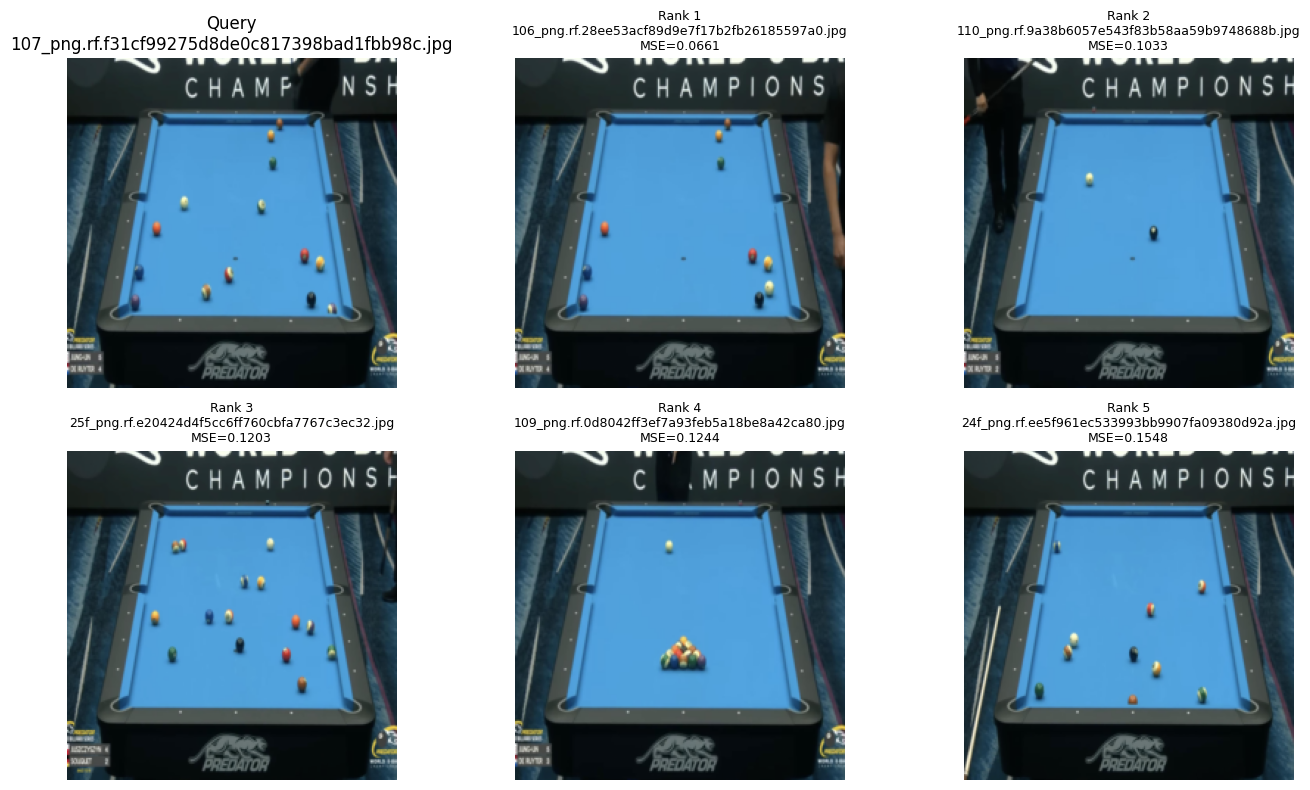

In [12]:
f, axarr = plt.subplots(2, 3, figsize=(14, 8))

axarr[0][0].imshow(query_image_denormalized)
axarr[0][0].set_title(f"Query\n{query_name}")
axarr[0][0].axis("off")

for j in range(1, 6):
    idx = top5_mse_idx[j - 1]
    img, name = retrieval_pool[idx]
    img_show = denormalize_image(img)

    axarr[j // 3][j % 3].imshow(img_show)
    axarr[j // 3][j % 3].set_title(
        f"Rank {j}\n{name}\nMSE={similarities_mse[idx]:.4f}",
        fontsize=9
    )
    axarr[j // 3][j % 3].axis("off")

plt.tight_layout()
plt.show()

- #### **Sensitivity to Image Translation**

To evaluate the robustness of MSE, the query image is artificially translated by 20 pixels to the right.

Although the billiard table state remains identical, the spatial position of every pixel changes. Since MSE compares images at the pixel level, even small geometric transformations can produce large distance values.

The translated query is then compared against the original query and against the top-ranked retrieved image.

MSE between query and translated query: 0.7441
MSE between query and top-1 retrieved image: 0.0661


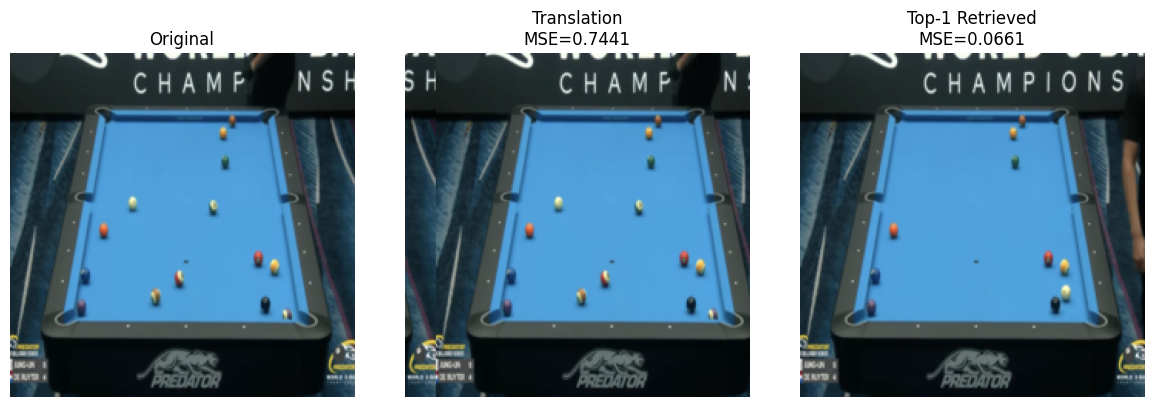

In [13]:
# Translate query image 5 pixels to the right
translate_query_image = torch.roll(query_image, shifts=20, dims=2)

sim_trans = mean_squared_error(
    query_image.detach().cpu().numpy(),
    translate_query_image.detach().cpu().numpy()
)

print(f"MSE between query and translated query: {sim_trans:.4f}")
print(f"MSE between query and top-1 retrieved image: {similarities_mse[top5_mse_idx[0]]:.4f}")

f, axarr = plt.subplots(1, 3, figsize=(12, 4))

axarr[0].imshow(query_image_denormalized)
axarr[0].set_title("Original")
axarr[0].axis("off")

axarr[1].imshow(denormalize_image(translate_query_image))
axarr[1].set_title(f"Translation\nMSE={sim_trans:.4f}")
axarr[1].axis("off")

top1_img, top1_name = retrieval_pool[top5_mse_idx[0]]
axarr[2].imshow(denormalize_image(top1_img))
axarr[2].set_title(f"Top-1 Retrieved\nMSE={similarities_mse[top5_mse_idx[0]]:.4f}")
axarr[2].axis("off")

plt.tight_layout()
plt.show()

- **Interpretation:**

```bash
MSE between query and translated query: 0.7441
MSE between query and top-1 retrieved image: 0.0661
```

The translated image represents exactly the same table state as the original query. However, its MSE distance is more than ten times larger than the distance to the top retrieved image.

This demonstrates that MSE is dominated by pixel alignment rather than semantic content, making it unsuitable for viewpoint-invariant retrieval.

- #### **MSE Observations**

    - MSE retrieves images with similar global appearance and camera pose.

    - Retrieval performance is strongly influenced by viewpoint and image alignment.

    - Images with different ball configurations can still obtain low MSE values if their overall appearance is similar.

    - A simple 20-pixel translation produces a substantially larger distance than many semantically different table states.
    
    - These results indicate that pixel-level similarity is not an appropriate representation for billiard-state retrieval.

<a id="ssim"></a>
### **Structural Similarity (SSIM) Retrieval**

Structural Similarity Index Measure (SSIM) compares images based on local luminance, contrast, and structural patterns.

Unlike MSE, where lower values indicate more similar images, SSIM is a similarity score: higher values indicate higher similarity.

Although SSIM is more perceptually meaningful than MSE, it still compares the full image structure and is therefore expected to remain sensitive to camera viewpoint and global image layout.

In [14]:
def get_topk_ssim(query_image, retrieval_pool, k=5):
    scores = np.zeros(len(retrieval_pool))

    query_np = query_image.detach().cpu().numpy()
    query_np_hwc = np.transpose(query_np, (1, 2, 0))

    for i in range(len(retrieval_pool)):
        candidate_image, _ = retrieval_pool[i]
        candidate_np = candidate_image.detach().cpu().numpy()
        candidate_np_hwc = np.transpose(candidate_np, (1, 2, 0))

        data_range = (
            max(query_np_hwc.max(), candidate_np_hwc.max())
            - min(query_np_hwc.min(), candidate_np_hwc.min())
        )

        scores[i] = ssim(
            query_np_hwc,
            candidate_np_hwc,
            channel_axis=2,
            data_range=data_range
        )

    topk_idx = np.argsort(scores)[::-1][:k]
    return topk_idx, scores, query_np_hwc

In [15]:
top5_ssim_idx, similarities_ssim, query_np_hwc = get_topk_ssim(
    query_image=query_image,
    retrieval_pool=retrieval_pool,
    k=5
)

In [16]:
print("Top-5 SSIM results:")

for rank, idx in enumerate(top5_ssim_idx, start=1):
    _, name = retrieval_pool[idx]

    print(
        f"{rank}. {name} | "
        f"SSIM = {similarities_ssim[idx]:.4f}"
    )

Top-5 SSIM results:
1. 106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg | SSIM = 0.9301
2. 109_png.rf.0d8042ff3ef7a93feb5a18be8a42ca80.jpg | SSIM = 0.8946
3. 110_png.rf.9a38b6057e543f83b58aa59b9748688b.jpg | SSIM = 0.8736
4. 25f_png.rf.e20424d4f5cc6ff760cbfa7767c3ec32.jpg | SSIM = 0.8425
5. 24f_png.rf.ee5f961ec533993bb9907fa09380d92a.jpg | SSIM = 0.8357


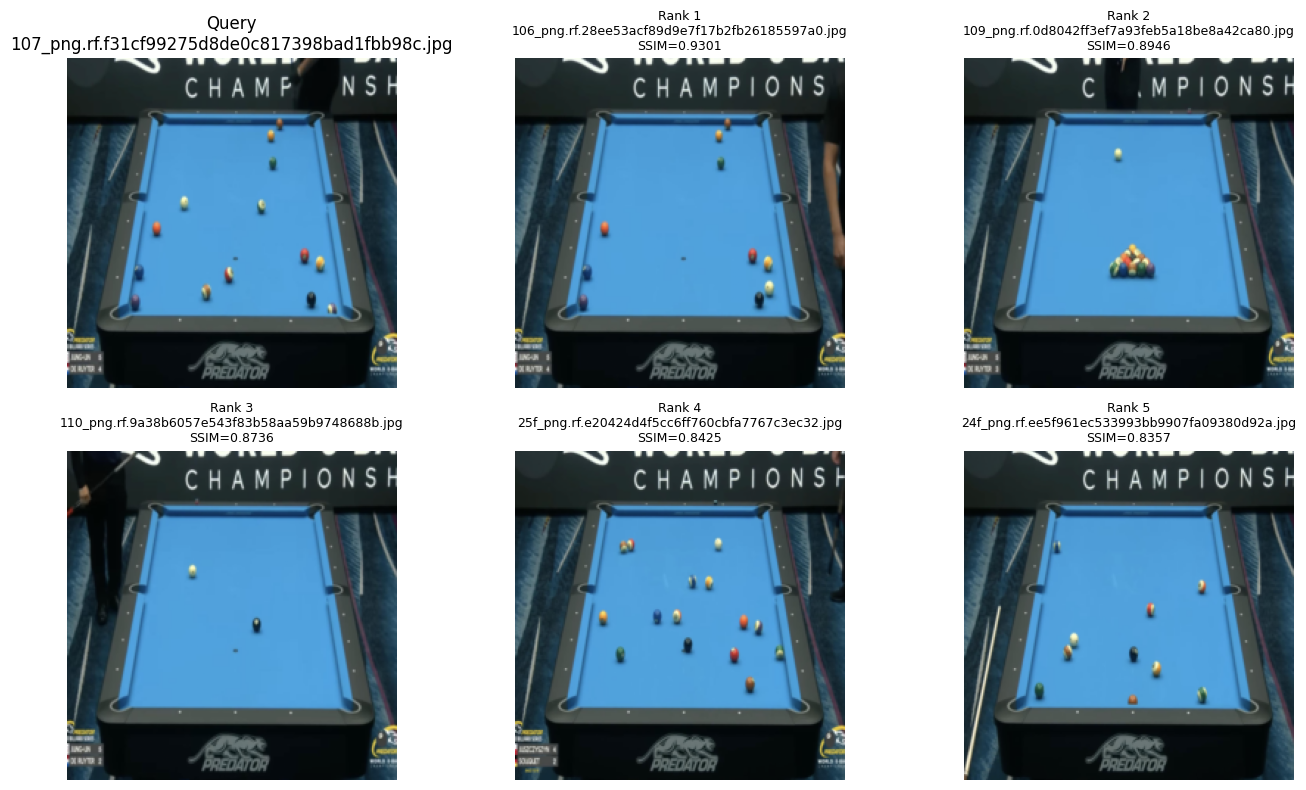

In [17]:
f, axarr = plt.subplots(2, 3, figsize=(14, 8))

axarr[0][0].imshow(query_image_denormalized)
axarr[0][0].set_title(f"Query\n{query_name}")
axarr[0][0].axis("off")

for j in range(1, 6):
    idx = top5_ssim_idx[j - 1]
    img, name = retrieval_pool[idx]
    img_show = denormalize_image(img)

    axarr[j // 3][j % 3].imshow(img_show)
    axarr[j // 3][j % 3].set_title(
        f"Rank {j}\n{name}\nSSIM={similarities_ssim[idx]:.4f}",
        fontsize=9
    )
    axarr[j // 3][j % 3].axis("off")

plt.tight_layout()
plt.show()

- #### **Sensitivity to Image Translation**

As with MSE, we evaluate how SSIM behaves when the query image is shifted by a small number of pixels. Although SSIM is more robust to local intensity variations and structural changes than MSE, it remains sensitive to spatial misalignment because corresponding image regions no longer overlap perfectly.

This experiment highlights that SSIM improves upon MSE but still lacks the viewpoint and geometric invariance required for robust billiard-table retrieval.

In [18]:
# Translate query image 20 pixels to the right
translate_query_image = torch.roll(query_image, shifts=20, dims=2)

translated_np = translate_query_image.detach().cpu().numpy()
translated_np_hwc = np.transpose(translated_np, (1, 2, 0))

data_range = (
    max(query_np_hwc.max(), translated_np_hwc.max())
    - min(query_np_hwc.min(), translated_np_hwc.min())
)

ssim_trans = ssim(
    query_np_hwc,
    translated_np_hwc,
    channel_axis=2,
    data_range=data_range
)

print(f"SSIM between query and translated query: {ssim_trans:.4f}")
print(f"SSIM between query and top-1 retrieved image: {similarities_ssim[top5_ssim_idx[0]]:.4f}")

SSIM between query and translated query: 0.4415
SSIM between query and top-1 retrieved image: 0.9301


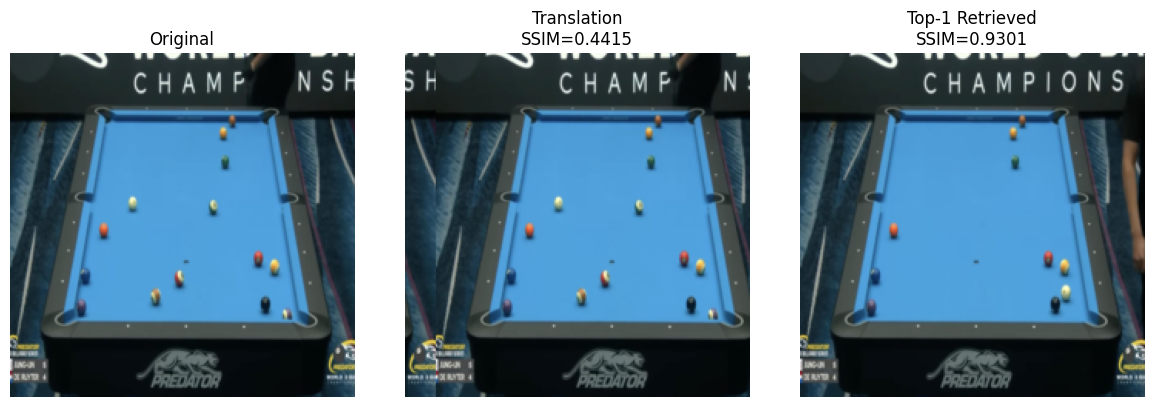

In [19]:
f, axarr = plt.subplots(1, 3, figsize=(12, 4))

axarr[0].imshow(query_image_denormalized)
axarr[0].set_title("Original")
axarr[0].axis("off")

axarr[1].imshow(denormalize_image(translate_query_image))
axarr[1].set_title(f"Translation\nSSIM={ssim_trans:.4f}")
axarr[1].axis("off")

top1_img, top1_name = retrieval_pool[top5_ssim_idx[0]]
axarr[2].imshow(denormalize_image(top1_img))
axarr[2].set_title(
    f"Top-1 Retrieved\nSSIM={similarities_ssim[top5_ssim_idx[0]]:.4f}"
)
axarr[2].axis("off")

plt.tight_layout()
plt.show()

- #### **SSIM Observations**

    - SSIM retrieves images with very similar global structure and viewpoint.

    - The top-ranked results share the same table orientation and broadcast-style camera framing.

    - However, some retrieved images have clearly different ball configurations.
    
    - This shows that SSIM improves over raw pixel distance but still does not directly represent the billiard-table state.

### **Complete Retrieval**

To evaluate the behaviour of the image-level baselines beyond a single query image, we repeat retrieval for all test queries.

For each query, we store the Top-5 retrieved images and their similarity scores for both MSE and SSIM.

In [21]:
K = 5

all_results = []

for q_idx in tqdm(range(len(query_data))):
    query_image, query_name = query_data[q_idx]

    topk_mse_idx, mse_scores = get_topk_mse(query_image, retrieval_pool, k=K)
    topk_ssim_idx, ssim_scores, _ = get_topk_ssim(query_image, retrieval_pool, k=K)

    row = {
        "query_idx": q_idx,
        "query_name": query_name,
    }

    for rank in range(K):
        mse_idx = topk_mse_idx[rank]
        _, mse_name = retrieval_pool[mse_idx]

        row[f"mse_rank{rank+1}_name"] = mse_name
        row[f"mse_rank{rank+1}_score"] = mse_scores[mse_idx]

        ssim_idx = topk_ssim_idx[rank]
        _, ssim_name = retrieval_pool[ssim_idx]

        row[f"ssim_rank{rank+1}_name"] = ssim_name
        row[f"ssim_rank{rank+1}_score"] = ssim_scores[ssim_idx]

    all_results.append(row)

results_df = pd.DataFrame(all_results)
results_df.head()

100%|██████████| 20/20 [02:03<00:00,  6.16s/it]


,query_idx,query_name,mse_rank1_name,mse_rank1_score,ssim_rank1_name,ssim_rank1_score,mse_rank2_name,mse_rank2_score,ssim_rank2_name,ssim_rank2_score,...,ssim_rank3_name,ssim_rank3_score,mse_rank4_name,mse_rank4_score,ssim_rank4_name,ssim_rank4_score,mse_rank5_name,mse_rank5_score,ssim_rank5_name,ssim_rank5_score
0,0,107_png.rf.f31cf99275d8de0c817398bad1fbb98c.jpg,106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg,0.066085,106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg,0.930092,110_png.rf.9a38b6057e543f83b58aa59b9748688b.jpg,0.103336,109_png.rf.0d8042ff3ef7a93feb5a18be8a42ca80.jpg,0.894604,...,110_png.rf.9a38b6057e543f83b58aa59b9748688b.jpg,0.873631,109_png.rf.0d8042ff3ef7a93feb5a18be8a42ca80.jpg,0.124375,25f_png.rf.e20424d4f5cc6ff760cbfa7767c3ec32.jpg,0.842535,24f_png.rf.ee5f961ec533993bb9907fa09380d92a.jpg,0.154769,24f_png.rf.ee5f961ec533993bb9907fa09380d92a.jpg,0.835679
1,1,111_png.rf.573bdb8149674c4469ce560c651c6a48.jpg,151_png.rf.dded9697689a87303c84573468e354a9.jpg,0.876005,171_png.rf.e0f78688a6d730302708d2eec60a4bdf.jpg,0.316488,163_png.rf.caf94b785a094d025843b480af8738cc.jpg,0.961579,151_png.rf.dded9697689a87303c84573468e354a9.jpg,0.308398,...,148_png.rf.ce6399c2c651b1e0c1ccbe0ed06b1038.jpg,0.292488,86_png.rf.ed680afb145347de62fa9e5dd2b90bbe.jpg,0.977824,139_png.rf.3b1d0480bfeb169028854cb472ea5f25.jpg,0.288163,91_png.rf.d78bae1b26a617eb6363e4345800eb54.jpg,1.008130,73_png.rf.16191fc07ebda5e8a83294c9c4fbd4bb.jpg,0.285293
2,2,115_png.rf.ed51d53dd5c384b1f26a2b6ece52ad69.jpg,116_png.rf.d62651a8a8690338109c790bb5e036bd.jpg,0.064994,116_png.rf.d62651a8a8690338109c790bb5e036bd.jpg,0.918376,119_png.rf.eff91a09289a82f634d7b231b06dbbdd.jpg,0.066739,119_png.rf.eff91a09289a82f634d7b231b06dbbdd.jpg,0.904289,...,117_png.rf.8cc2251ee5c44b6bd3734b39795c7cc9.jpg,0.873800,120_png.rf.ad88298a705a565adab2f06fe083c434.jpg,0.132570,120_png.rf.ad88298a705a565adab2f06fe083c434.jpg,0.855577,109_png.rf.0d8042ff3ef7a93feb5a18be8a42ca80.jpg,0.164866,109_png.rf.0d8042ff3ef7a93feb5a18be8a42ca80.jpg,0.760121
3,3,118_png.rf.3e82e1f3d657302b61a62c113271b753.jpg,10a_png.rf.bdc9984ba169594ea32b012098ad10dd.jpg,0.788561,4a_png.rf.a6bb5c5706fd8628eb53d34a122cf441.jpg,0.331783,163_png.rf.caf94b785a094d025843b480af8738cc.jpg,0.833632,10a_png.rf.bdc9984ba169594ea32b012098ad10dd.jpg,0.330918,...,162_png.rf.faeb269d920f46126201519c32565e6d.jpg,0.324378,4a_png.rf.a6bb5c5706fd8628eb53d34a122cf441.jpg,0.857439,148_png.rf.ce6399c2c651b1e0c1ccbe0ed06b1038.jpg,0.317308,162_png.rf.faeb269d920f46126201519c32565e6d.jpg,0.864728,169_png.rf.db5c4e716dac3be45044ffb904f0202d.jpg,0.316799
4,4,134_png.rf.eafc70891a991c969df70bd817a63375.jpg,150_png.rf.d73327d3ac59114d003f79ec28e80c36.jpg,0.021070,150_png.rf.d73327d3ac59114d003f79ec28e80c36.jpg,0.936027,131_png.rf.593310c39f8835ed0786033b6690de45.jpg,0.021407,131_png.rf.593310c39f8835ed0786033b6690de45.jpg,0.935785,...,11t_png.rf.bfd0b31ac2643b2a5d526f315fbf1812.jpg,0.930137,157_png.rf.27c930f4a54872dbae1acb7faf69b5af.jpg,0.026413,153_png.rf.6e13f8c07bec12bd7e4094e6179bd363.jpg,0.928607,153_png.rf.6e13f8c07bec12bd7e4094e6179bd363.jpg,0.027030,157_png.rf.27c930f4a54872dbae1acb7faf69b5af.jpg,0.922991


In [ ]:
results_path = RESULTS_DIR / "retrieval_results_mse_ssim.csv"
results_df.to_csv(results_path, index=False)

print(f"Saved retrieval results to: {results_path}")

Saved retrieval results to: /Users/sarataboas/Desktop/master/2_semester/computer_vision/8_BallPool_ComputerVision/detection_and_retrieval/retrieval/outputs/experiment_01/retrieval_results_mse_ssim.csv


In [ ]:
score_summary = results_df[
    [
        "query_name",
        "mse_rank1_name",
        "mse_rank1_score",
        "ssim_rank1_name",
        "ssim_rank1_score",
    ]
]

score_summary

,query_name,mse_rank1_name,mse_rank1_score,ssim_rank1_name,ssim_rank1_score
0,107_png.rf.f31cf99275d8de0c817398bad1fbb98c.jpg,106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg,0.066085,106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg,0.930092
1,111_png.rf.573bdb8149674c4469ce560c651c6a48.jpg,151_png.rf.dded9697689a87303c84573468e354a9.jpg,0.876005,171_png.rf.e0f78688a6d730302708d2eec60a4bdf.jpg,0.316488
2,115_png.rf.ed51d53dd5c384b1f26a2b6ece52ad69.jpg,116_png.rf.d62651a8a8690338109c790bb5e036bd.jpg,0.064994,116_png.rf.d62651a8a8690338109c790bb5e036bd.jpg,0.918376
3,118_png.rf.3e82e1f3d657302b61a62c113271b753.jpg,10a_png.rf.bdc9984ba169594ea32b012098ad10dd.jpg,0.788561,4a_png.rf.a6bb5c5706fd8628eb53d34a122cf441.jpg,0.331783
4,134_png.rf.eafc70891a991c969df70bd817a63375.jpg,150_png.rf.d73327d3ac59114d003f79ec28e80c36.jpg,0.021070,150_png.rf.d73327d3ac59114d003f79ec28e80c36.jpg,0.936027
5,136_png.rf.e99c3dfd6e84ce294cdabc3bb5ee8a75.jpg,150_png.rf.d73327d3ac59114d003f79ec28e80c36.jpg,0.020876,138_png.rf.8f90a2d90a20d34006c446dc14a852c0.jpg,0.938929
6,140_png.rf.6645e10bad5cf3f197b71ddb6b34e6b4.jpg,145_png.rf.223f80e4aff2b64f2711cd186532e118.jpg,0.071852,145_png.rf.223f80e4aff2b64f2711cd186532e118.jpg,0.910801
7,144_png.rf.5c3890791bfecba0869eafb73fa3a4f5.jpg,150_png.rf.d73327d3ac59114d003f79ec28e80c36.jpg,0.021602,143_png.rf.4ddb999b17c98b304ca30654dfd0b01c.jpg,0.969666
8,181_png.rf.23ccd3b4b31a6fef484f7f0d25cf89d7.jpg,186_png.rf.6e7fc2cce220b40aa716f4d90902659a.jpg,1.050103,82_png.rf.d084be48b241d855d5a48b16f9595b2a.jpg,0.294290
9,185_png.rf.d2a971d3a33d7f290e313be493525277.jpg,187_png.rf.b5c19d9e137330a99f4a5885ac5c7d73.jpg,0.685727,10a_png.rf.bdc9984ba169594ea32b012098ad10dd.jpg,0.315381


This table allows us to compare whether MSE and SSIM retrieve the same nearest neighbours for each query. In general, both methods tend to favour images with similar global appearance and camera viewpoint, rather than explicitly matching the billiard-ball configuration.

### **Experiment 01 Conclusion**

MSE and SSIM operate directly on image pixels and therefore favour images with similar appearance, alignment, and camera viewpoint.

Although these methods can retrieve visually similar scenes, they do not reliably capture the semantic arrangement of billiard balls on the table.

The translation experiment further highlights the lack of invariance to geometric transformations. These limitations motivate the use of feature-based representations in the next experiment.